# 🐦 BirdCLEF 2025 — GAN para Generación de Espectrogramas Mel

**Proyecto IA II**

Este notebook combina:
- 📊 **Datos**: Dataset BirdCLEF-2025 (Kaggle) — grabaciones de audio de especies de aves
- 🤖 **Modelo**: GAN con arquitectura Encoder-Bottleneck-Decoder para reconstruir y generar espectrogramas Mel

### Pipeline general
1. Descarga del dataset BirdCLEF-2025
2. Preprocesamiento: generación de espectrogramas Mel normalizados
3. Entrenamiento de la GAN (Generator + Discriminator)
4. Visualización de resultados: espectrogramas reales vs. generados
5. Evaluación cualitativa

In [1]:
#@title **Dependencias**
!pip install kagglehub librosa torch torchvision tqdm matplotlib numpy pandas --quiet

In [2]:
#@title **Librerías**
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.utils as vutils

from tqdm import tqdm
import kagglehub

# ── Dispositivo ──────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo en uso: {device}")

Dispositivo en uso: cuda


In [27]:
#@title **Hyperparametros a cambiar**
# ── Audio / Espectrograma ─────────────────────────────────────────────────────
MAX_AUDIO_DURATION_SEC = 7   # Duración máxima de cada clip en segundos
TARGET_MEL_HEIGHT      = 64    # Bandas Mel  → altura de la imagen
TARGET_MEL_WIDTH       = 64    # Fotogramas  → ancho de la imagen (igual a IMAGE_SIZE de la GAN)
N_FFT                  = 2048
HOP_LENGTH             = 512

# ── Dataset ───────────────────────────────────────────────────────────────────
TOP_N_SPECIES   = 15   # Número de especies más frecuentes a usar
MAX_PER_SPECIES =   50 # Máximo de audios por especie

# ── GAN ───────────────────────────────────────────────────────────────────────
IMAGE_SIZE  = 64       # Debe coincidir con TARGET_MEL_HEIGHT y TARGET_MEL_WIDTH
CHANNELS    = 1        # Espectrogramas en escala de grises
LATENT_DIM  = 128      # Dimensión del cuello de botella
BATCH_SIZE  = 32
EPOCHS      = 54
LR          = 0.0001

print("Hiperparámetros configurados correctamente.")

Hiperparámetros configurados correctamente.


In [4]:

#@title **Dataset BirdCLEF-2025**
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_f6736a1438329933cf2af4cb089b7c12'

path = kagglehub.competition_download('birdclef-2025')
print(f"Dataset descargado en: {path}")
print("Contenido:", os.listdir(path))

100%|██████████| 11.5G/11.5G [05:12<00:00, 39.5MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/competitions/birdclef-2025
Contenido: ['sample_submission.csv', 'taxonomy.csv', 'recording_location.txt', 'train_soundscapes', 'train.csv', 'train_audio', 'test_soundscapes']


In [5]:
#@title **Exploración dataset**
train_df = pd.read_csv(os.path.join(path, 'train.csv'))

print(f"Total de grabaciones : {len(train_df)}")
print(f"Especies únicas      : {train_df['primary_label'].nunique()}")
print("\nColumnas disponibles:", train_df.columns.tolist())
print("\nPrimeras filas:")
train_df.head()

Total de grabaciones : 28564
Especies únicas      : 206

Columnas disponibles: ['primary_label', 'secondary_labels', 'type', 'filename', 'collection', 'rating', 'url', 'latitude', 'longitude', 'scientific_name', 'common_name', 'author', 'license']

Primeras filas:


,primary_label,secondary_labels,type,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license
0,1139490,[''],[''],1139490/CSA36385.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
1,1139490,[''],[''],1139490/CSA36389.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
2,1192948,[''],[''],1192948/CSA36358.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
3,1192948,[''],[''],1192948/CSA36366.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.2800,-73.8582,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
4,1192948,[''],[''],1192948/CSA36373.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0


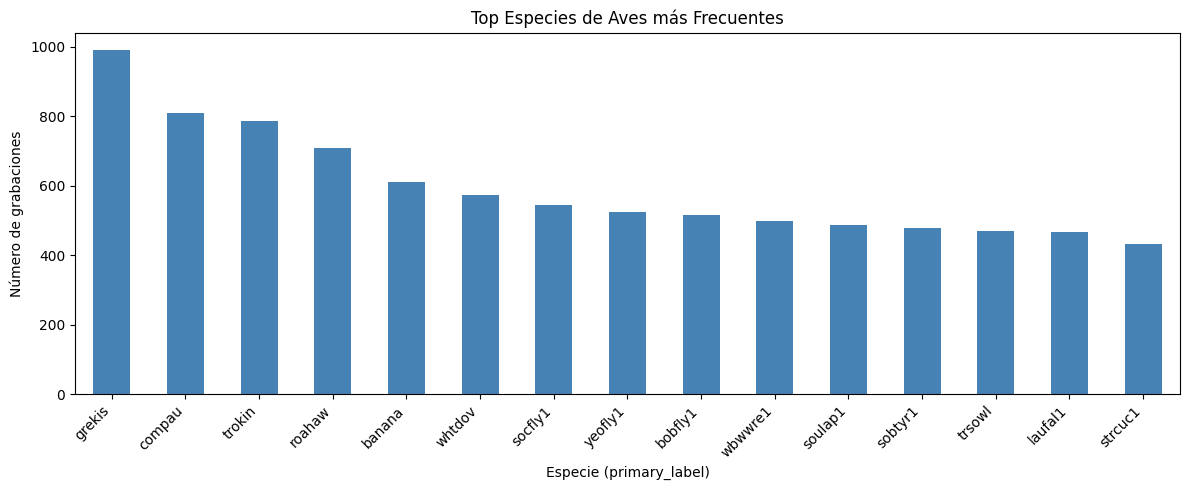

In [29]:
#@title **Especies a estudiar**
# Top 10 especies más frecuentes
top_10_species = train_df['primary_label'].value_counts().head(TOP_N_SPECIES)

plt.figure(figsize=(12, 5))
top_10_species.plot(kind='bar', color='steelblue')
plt.title('Top Especies de Aves más Frecuentes')
plt.xlabel('Especie (primary_label)')
plt.ylabel('Número de grabaciones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [30]:
#@title **Subconjunto de entrenamiento**

top_5_labels = top_10_species.head(TOP_N_SPECIES).index.tolist()
print("Especies seleccionadas:", top_5_labels)

subset_df = pd.DataFrame()
for label in top_5_labels:
    species_data = train_df[train_df['primary_label'] == label]
    limited = species_data.sample(n=min(MAX_PER_SPECIES, len(species_data)), random_state=42)
    subset_df = pd.concat([subset_df, limited])

subset_df = subset_df.reset_index(drop=True)
print(f"\nTotal de audios en el subconjunto: {len(subset_df)}")
print(subset_df['primary_label'].value_counts())

Especies seleccionadas: ['grekis', 'compau', 'trokin', 'roahaw', 'banana', 'whtdov', 'socfly1', 'yeofly1', 'bobfly1', 'wbwwre1', 'soulap1', 'sobtyr1', 'trsowl', 'laufal1', 'strcuc1']

Total de audios en el subconjunto: 750
primary_label
grekis     50
compau     50
trokin     50
roahaw     50
banana     50
whtdov     50
socfly1    50
yeofly1    50
bobfly1    50
wbwwre1    50
soulap1    50
sobtyr1    50
trsowl     50
laufal1    50
strcuc1    50
Name: count, dtype: int64


In [31]:
#@title **Generación de espectogramas MeI**
X_mels   = []
y_labels = []

for _, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc="Generando espectrogramas"):
    audio_path = os.path.join(path, 'train_audio', row['filename'])
    try:
        y_audio, sr = librosa.load(audio_path, sr=None, duration=MAX_AUDIO_DURATION_SEC)

        mel = librosa.feature.melspectrogram(
            y=y_audio, sr=sr,
            n_fft=N_FFT, hop_length=HOP_LENGTH,
            n_mels=TARGET_MEL_HEIGHT
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Ajustar ancho a TARGET_MEL_WIDTH
        mel_fixed = librosa.util.fix_length(
            mel_db, size=TARGET_MEL_WIDTH, axis=1,
            constant_values=np.min(mel_db)
        )

        # Normalizar a [0, 1]
        mel_norm = (mel_fixed - mel_fixed.min()) / (mel_fixed.max() - mel_fixed.min() + 1e-8)

        X_mels.append(mel_norm)
        y_labels.append(row['primary_label'])

    except Exception as e:
        print(f"  ⚠️  Error en {row['filename']}: {e}")

X_mels   = np.array(X_mels)    # (N, 64, 64)
y_labels = np.array(y_labels)

print(f"\nEspectrogramas generados: {X_mels.shape}")
print(f"Etiquetas               : {y_labels.shape}")

Generando espectrogramas: 100%|██████████| 750/750 [00:20<00:00, 36.66it/s]


Espectrogramas generados: (750, 64, 64)
Etiquetas               : (750,)


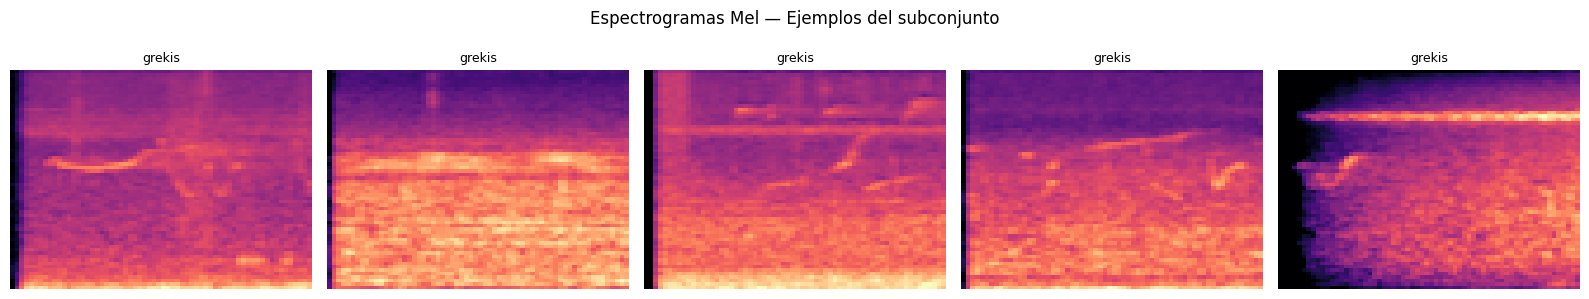

In [32]:
#@title **Visualización espectrogramas**
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for i in range(5):
    axes[i].imshow(X_mels[i], cmap='magma', origin='lower', aspect='auto')
    axes[i].set_title(y_labels[i], fontsize=9)
    axes[i].axis('off')
plt.suptitle('Espectrogramas Mel — Ejemplos del subconjunto')
plt.tight_layout()
plt.show()

In [33]:
#@title **DataLoader para PyTorch**
# (N, 64, 64)  →  (N, 1, 64, 64)  y re-escalar a [-1, 1]
X_tensor = torch.tensor(X_mels[:, np.newaxis, :, :], dtype=torch.float32)
X_tensor = X_tensor * 2.0 - 1.0   # [0,1] → [-1,1]

# Codificar etiquetas (para uso futuro / condicional)
le = LabelEncoder()
y_encoded = torch.tensor(le.fit_transform(y_labels), dtype=torch.long)
num_classes = len(le.classes_)

print(f"Tensor de entrada : {X_tensor.shape}  rango [{X_tensor.min():.2f}, {X_tensor.max():.2f}]")
print(f"Clases            : {le.classes_}")

dataset    = TensorDataset(X_tensor, y_encoded)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Batches por época : {len(dataloader)}")

Tensor de entrada : torch.Size([750, 1, 64, 64])  rango [-1.00, 1.00]
Clases            : ['banana' 'bobfly1' 'compau' 'grekis' 'laufal1' 'roahaw' 'sobtyr1'
 'socfly1' 'soulap1' 'strcuc1' 'trokin' 'trsowl' 'wbwwre1' 'whtdov'
 'yeofly1']
Batches por época : 23


## Arquitectura de la GAN

### Generator (Autoencoder convolucional)
- **Encoder**: comprime el espectrograma a un cuello de botella de dimensión `LATENT_DIM`.
- **Decoder**: reconstruye el espectrograma a partir de la representación latente.
- El objetivo del Generator es **engañar al Discriminator** produciendo espectrogramas indistinguibles de los reales.

### Discriminator
- CNN que clasifica cada espectrograma como **real** (1) o **generado** (0).

In [34]:
class Generator(nn.Module):
    """Autoencoder convolucional que reconstruye espectrogramas Mel."""

    def __init__(self):
        super(Generator, self).__init__()

        # Encoder: 64x64 → 4x4
        self.encoder = nn.Sequential(
            nn.Conv2d(CHANNELS, 64, 4, 2, 1),           # → 32x32
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),                # → 16x16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),               # → 8x8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 2, 1),               # → 4x4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2)
        )

        # Cuello de botella: 4x4 → 1x1
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, LATENT_DIM, 4, 1, 0),        # → 1x1
            nn.ReLU()
        )

        # Decoder: 1x1 → 64x64
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(LATENT_DIM, 512, 4, 1, 0),   # → 4x4
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),           # → 8x8
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),           # → 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),            # → 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, CHANNELS, 4, 2, 1),       # → 64x64
            nn.Tanh()                                        # Salida en [-1, 1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x)
        return x


class Discriminator(nn.Module):
    """Clasificador CNN: real (1) vs. generado (0)."""

    def __init__(self):
        super(Discriminator, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(CHANNELS, 64, 4, 2, 1),           # → 32x32
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),                # → 16x16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),               # → 8x8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 2, 1),               # → 4x4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2)
        )

        self.classifier = nn.Sequential(
            nn.Conv2d(512, 1, 4, 1, 0),                 # → 1x1
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.view(-1)


G = Generator().to(device)
D = Discriminator().to(device)

print("=== Generator ===")
print(G)
print("\n=== Discriminator ===")
print(D)

=== Generator ===
Generator(
  (encoder): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2)
  )
  (bottleneck): Sequential(
    (0): Conv2d(512, 128, kernel_size=(4, 4), stride=(1, 1))
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 512, kernel_size=(4, 4), stride=(1, 1))
    (1)

In [35]:
#@title **Funciones de Pérdida y Optimizadores**
criterion         = nn.BCELoss()   # Pérdida adversarial
reconstruction_loss = nn.L1Loss() # Pérdida de reconstrucción pixel a pixel

optimizer_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

print("Optimizadores e inicializados.")

Optimizadores e inicializados.


## **Entrenamiento de la GAN**

**Lógica del entrenamiento**:

1. **Discriminator**: aprende a distinguir espectrogramas reales de los generados por G.
2. **Generator**: minimiza una pérdida combinada:
   - `adversarial_loss`: engañar al Discriminator.
   - `reconstruction_loss × 100`: mantener la fidelidad estructural al espectrograma original.

In [36]:
#@title **Entrenamiento**

history_loss_D = []
history_loss_G = []

for epoch in range(EPOCHS):
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0

    loop = tqdm(dataloader, desc=f"Época [{epoch+1}/{EPOCHS}]", leave=False)

    for real_images, _ in loop:
        real_images = real_images.to(device)
        batch_size  = real_images.size(0)

        real_labels = torch.ones(batch_size).to(device)
        fake_labels = torch.zeros(batch_size).to(device)

        # ── Entrenar Discriminator ────────────────────────────────────────────
        optimizer_D.zero_grad()

        output_real = D(real_images)
        loss_real   = criterion(output_real, real_labels)

        fake_images  = G(real_images)
        output_fake  = D(fake_images.detach())
        loss_fake    = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # ── Entrenar Generator ───────────────────────────────────────────────
        optimizer_G.zero_grad()

        fake_images  = G(real_images)
        output_fake  = D(fake_images)

        adv_loss = criterion(output_fake, real_labels)          # Engañar al D
        rec_loss = reconstruction_loss(fake_images, real_images) # Fidelidad

        loss_G = adv_loss + 100 * rec_loss
        loss_G.backward()
        optimizer_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()

        loop.set_postfix(loss_D=f"{loss_D.item():.4f}", loss_G=f"{loss_G.item():.4f}")

    avg_D = epoch_loss_D / len(dataloader)
    avg_G = epoch_loss_G / len(dataloader)
    history_loss_D.append(avg_D)
    history_loss_G.append(avg_G)

    if (epoch + 1) % 10 == 0:
        print(f"Época {epoch+1:3d}/{EPOCHS}  |  loss_D: {avg_D:.4f}  |  loss_G: {avg_G:.4f}")

print("\n✅ Entrenamiento completado.")

Época  10/54  |  loss_D: 0.6325  |  loss_G: 17.8570


Época  20/54  |  loss_D: 0.8679  |  loss_G: 15.9790


Época  30/54  |  loss_D: 0.9501  |  loss_G: 14.6603


Época  40/54  |  loss_D: 0.8552  |  loss_G: 13.8509


Época  50/54  |  loss_D: 0.9314  |  loss_G: 13.4339



✅ Entrenamiento completado.


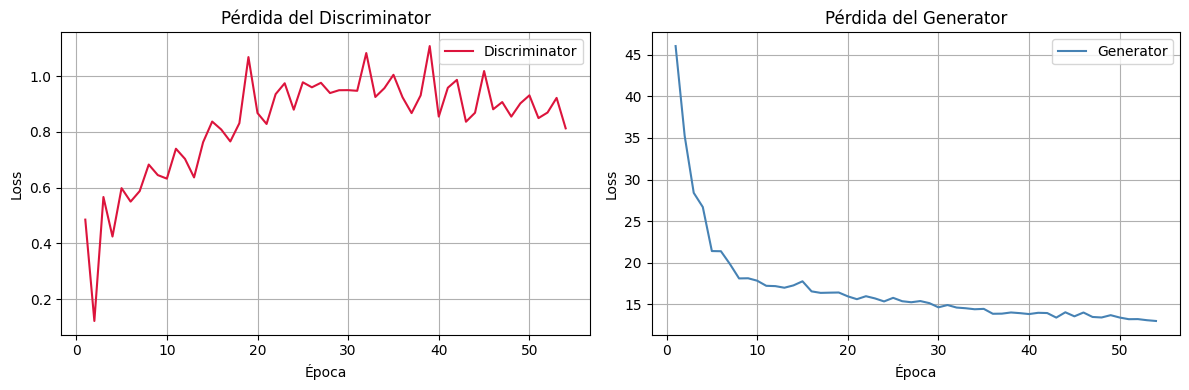

In [37]:
#@title **Curvas de pérdida**
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_loss_D, label='Discriminator', color='crimson')
plt.title('Pérdida del Discriminator')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_loss_G, label='Generator', color='steelblue')
plt.title('Pérdida del Generator')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

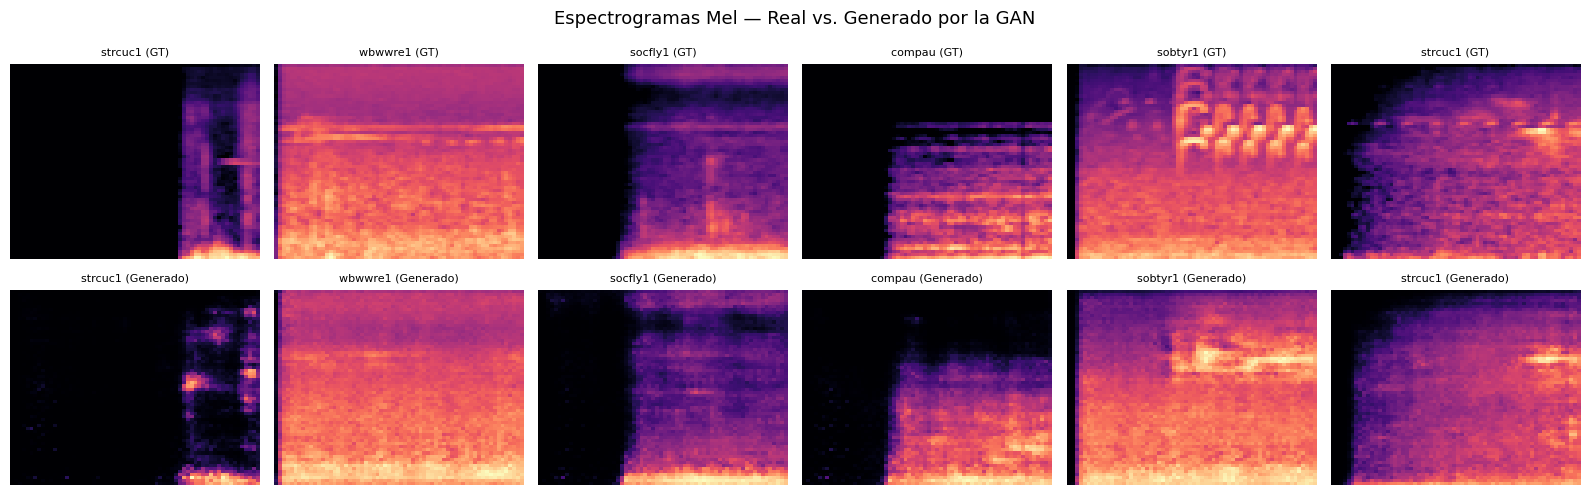

In [38]:
#@title **Comparativa de Espectogramas**
G.eval()

with torch.no_grad():
    sample_images, sample_labels = next(iter(dataloader))
    sample_images = sample_images.to(device)
    generated     = G(sample_images)

    real_np = sample_images.cpu().numpy()
    fake_np = generated.cpu().numpy()

n_show = 6
fig, axes = plt.subplots(2, n_show, figsize=(16, 5))

for i in range(n_show):
    species_label = le.inverse_transform([sample_labels[i].item()])[0]

    # Fila 0 — Real
    axes[0, i].imshow(real_np[i, 0], cmap='magma', origin='lower', aspect='auto')
    axes[0, i].set_title(f"{species_label} (GT)", fontsize=8)
    axes[0, i].axis('off')

    # Fila 1 — Generado
    axes[1, i].imshow(fake_np[i, 0], cmap='magma', origin='lower', aspect='auto')
    axes[1, i].set_title(f"{species_label} (Generado)", fontsize=8)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Real',      fontsize=12)
axes[1, 0].set_ylabel('Generado',  fontsize=12)

plt.suptitle('Espectrogramas Mel — Real vs. Generado por la GAN', fontsize=13)
plt.tight_layout()
plt.show()

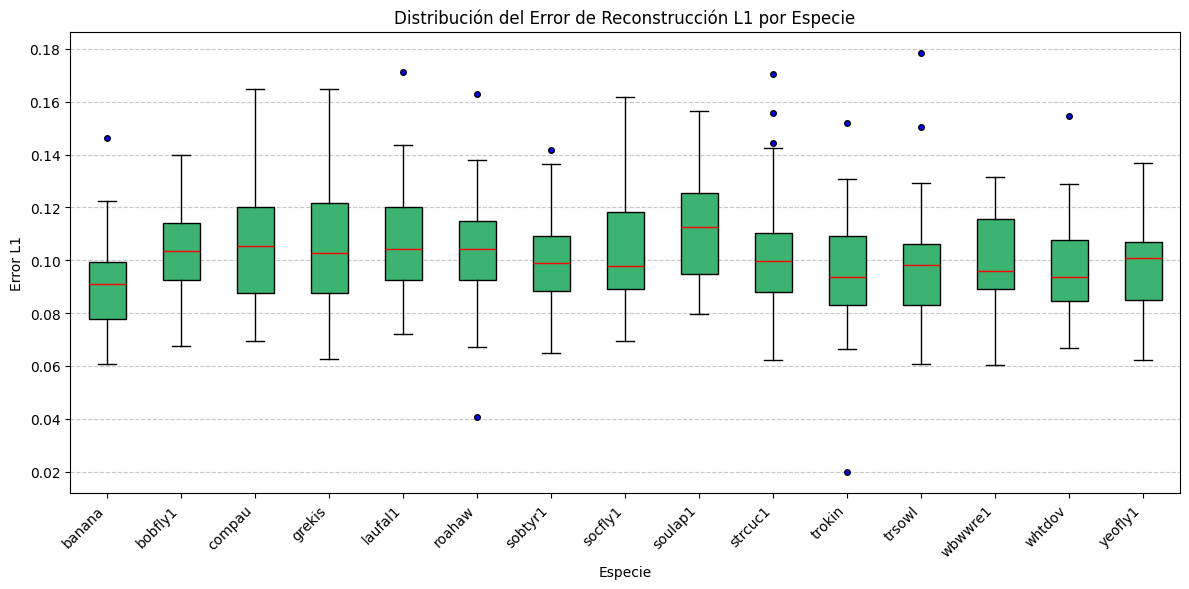

Errores L1 promedio:
  banana              : 0.0906 ± 0.0164
  bobfly1             : 0.1026 ± 0.0148
  compau              : 0.1054 ± 0.0222
  grekis              : 0.1037 ± 0.0228
  laufal1             : 0.1071 ± 0.0188
  roahaw              : 0.1047 ± 0.0201
  sobtyr1             : 0.1002 ± 0.0168
  socfly1             : 0.1024 ± 0.0206
  soulap1             : 0.1115 ± 0.0202
  strcuc1             : 0.1022 ± 0.0211
  trokin              : 0.0957 ± 0.0212
  trsowl              : 0.0979 ± 0.0209
  wbwwre1             : 0.0998 ± 0.0182
  whtdov              : 0.0971 ± 0.0166
  yeofly1             : 0.0973 ± 0.0168


In [39]:
#@title **Error de reconstrucción**
G.eval()
species_errors = {sp: [] for sp in le.classes_}

with torch.no_grad():
    for images, labels in dataloader:
        images    = images.to(device)
        generated = G(images)
        errors    = torch.abs(images - generated).mean(dim=(1, 2, 3)).cpu().numpy()
        for err, lbl in zip(errors, labels.numpy()):
            species_errors[le.inverse_transform([lbl])[0]].append(err)

# Prepare data for box plot
plot_data = [species_errors[sp] for sp in le.classes_]
species_labels = le.classes_

plt.figure(figsize=(12, 6))
plt.boxplot(plot_data, tick_labels=species_labels, patch_artist=True,
            boxprops=dict(facecolor='mediumseagreen', color='black'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(markerfacecolor='blue', marker='o', markersize=4))
plt.title('Distribución del Error de Reconstrucción L1 por Especie')
plt.xlabel('Especie')
plt.ylabel('Error L1')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Optional: Display mean and std as before, or refine this output
mean_errors  = {sp: np.mean(errs) for sp, errs in species_errors.items() if errs}
std_errors   = {sp: np.std(errs)  for sp, errs in species_errors.items() if errs}

species_list = list(mean_errors.keys())
means        = [mean_errors[s] for s in species_list]
stds         = [std_errors[s]  for s in species_list]

print("Errores L1 promedio:")
for sp, m, s in zip(species_list, means, stds):
    print(f"  {sp:20s}: {m:.4f} \u00b1 {s:.4f}")

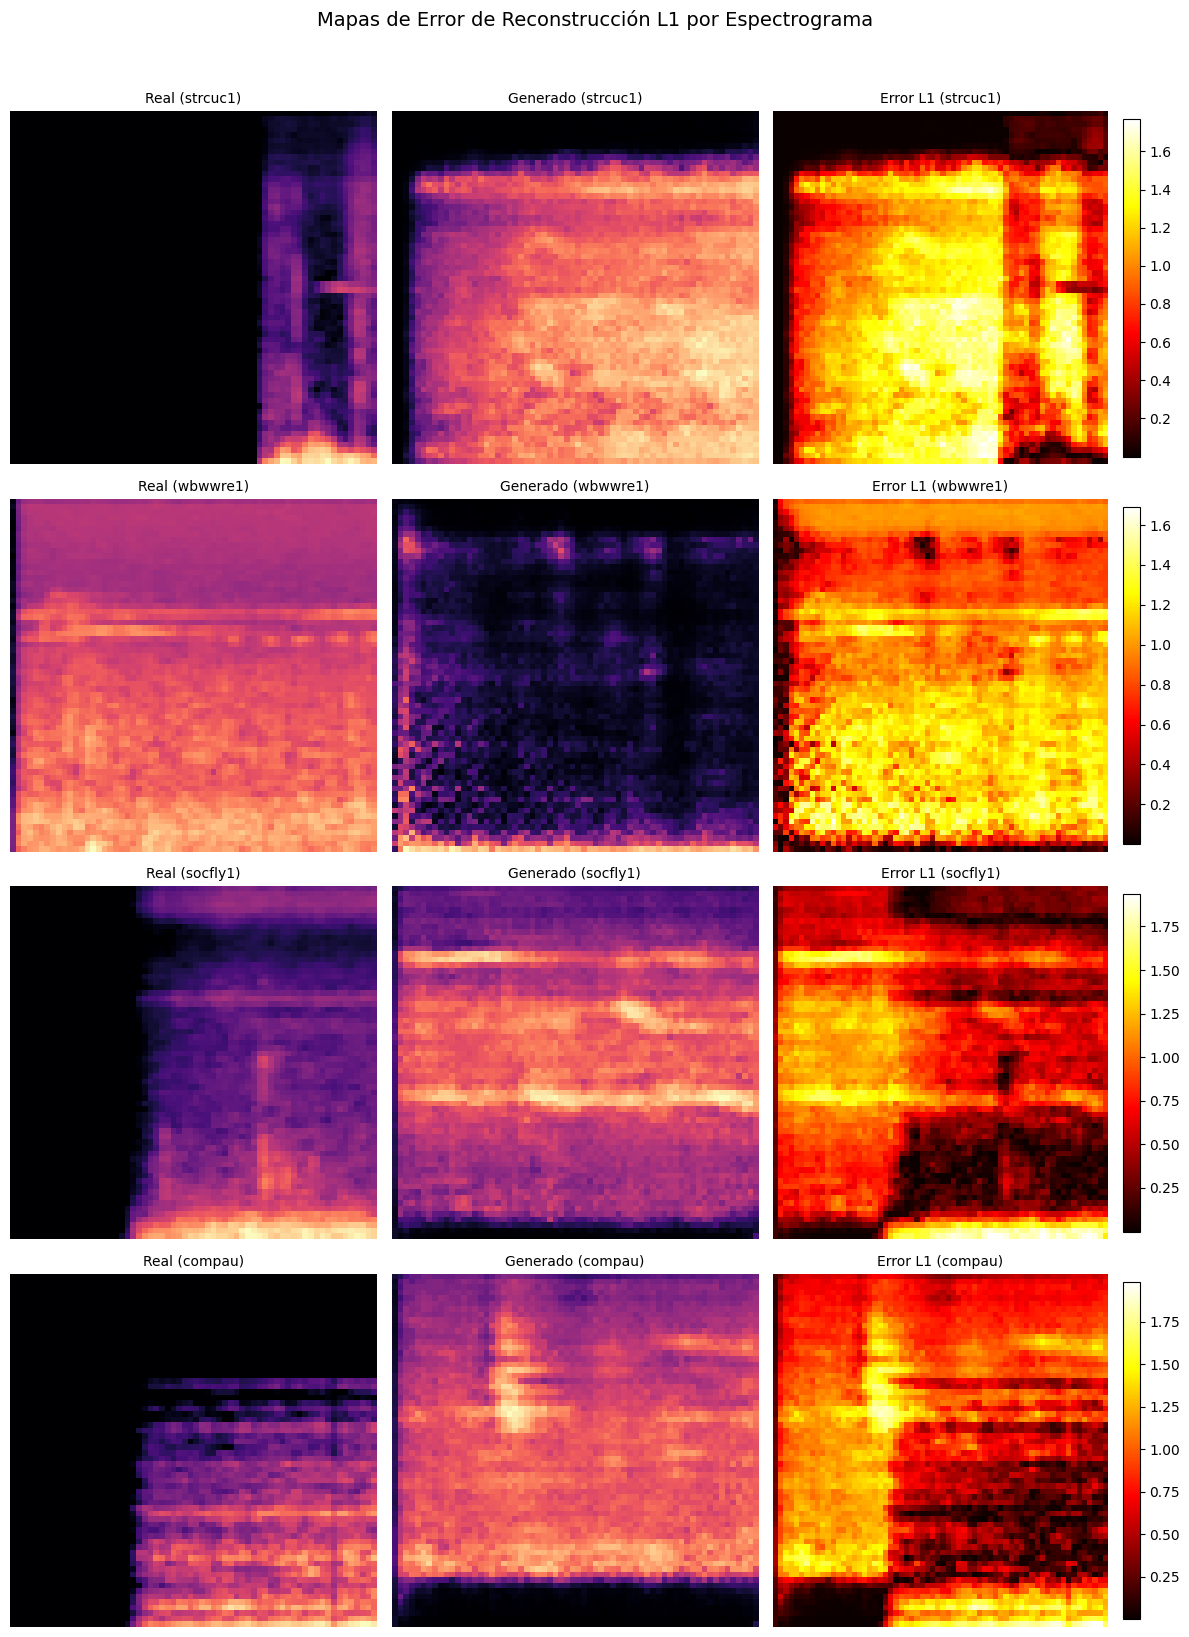

In [40]:
#@title **Error de Reconstrucción**

G.eval()
with torch.no_grad():
    try:
        _ = sample_images.cpu().numpy() # Just to check if it exists and is accessible
        _ = generated.cpu().numpy()
        _ = sample_labels.cpu().numpy()
    except NameError:
        sample_images, sample_labels = next(iter(dataloader))
        sample_images = sample_images.to(device)
        generated = G(sample_images)

    real_images_np = sample_images.cpu().numpy()
    generated_images_np = generated.cpu().numpy()


    error_maps = np.abs(real_images_np - generated_images_np)

n_display = 4  # Número de ejemplos a mostrar

fig, axes = plt.subplots(n_display, 3, figsize=(12, 4 * n_display))

for i in range(n_display):
    species_label = le.inverse_transform([sample_labels[i].item()])[0]

    # Espectrograma Real
    axes[i, 0].imshow(real_images_np[i, 0], cmap='magma', origin='lower', aspect='auto')
    axes[i, 0].set_title(f"Real ({species_label})", fontsize=10)
    axes[i, 0].axis('off')

    # Espectrograma Generado
    axes[i, 1].imshow(generated_images_np[i, 0], cmap='magma', origin='lower', aspect='auto')
    axes[i, 1].set_title(f"Generado ({species_label})", fontsize=10)
    axes[i, 1].axis('off')

    # Mapa de Error
    im = axes[i, 2].imshow(error_maps[i, 0], cmap='hot', origin='lower', aspect='auto')
    axes[i, 2].set_title(f"Error L1 ({species_label})", fontsize=10)
    axes[i, 2].axis('off')
    # Añadir barra de color para el mapa de error
    fig.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.suptitle('Mapas de Error de Reconstrucción L1 por Espectrograma', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 15. Guardado de los modelos

In [18]:
torch.save(G.state_dict(), 'generator_birdclef.pth')
torch.save(D.state_dict(), 'discriminator_birdclef.pth')
print("✅ Modelos guardados: generator_birdclef.pth  |  discriminator_birdclef.pth")

✅ Modelos guardados: generator_birdclef.pth  |  discriminator_birdclef.pth


## 16. (Opcional) Carga de modelos e inferencia

Puedes cargar los modelos guardados y generar espectrogramas sin reentrenar.

In [ ]:
G_loaded = Generator().to(device)
G_loaded.load_state_dict(torch.load('generator_birdclef.pth', map_location=device))
G_loaded.eval()

with torch.no_grad():
    sample, labels = next(iter(dataloader))
    sample     = sample.to(device)
    generated  = G_loaded(sample)

print("Modelo cargado y listo para inferencia.")
print(f"Forma de la salida generada: {generated.shape}")

Modelo cargado y listo para inferencia.
Forma de la salida generada: torch.Size([32, 1, 64, 64])
